# Batch 2 — Evaluation

Answers the four questions the project plan asks of this batch, directly
from the results in `batch2_results.csv`:

1. Did SMOTE/sampling improve recall?
2. What happened to precision?
3. Did PR-AUC improve?
4. Did removing redundant features help?

Every comparison here is against each model's own Batch 1 baseline (same
model, same feature set, no sampling) — not against other models — since
the question is "did this change help," not "which model is best."


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')


## 1. Paths & Load Results

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'Models_Batch_2' else Path.cwd()
BATCH_DIR = PROJECT_ROOT / 'Models_Batch_2'
ARTIFACTS_DIR = BATCH_DIR / 'artifacts'
FIGURES_DIR = BATCH_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = PROJECT_ROOT / 'results'

results_df = pd.read_csv(ARTIFACTS_DIR / 'batch2_results.csv')
# pandas' read_csv treats the literal string "None" as a missing-value token by default,
# so a stored Sampling_Technique of 'None' round-trips back as NaN — normalize it back so
# the '== None' filters below work as intended.
results_df['Sampling_Technique'] = results_df['Sampling_Technique'].fillna('None')
print(f"Loaded {len(results_df)} configuration results")
results_df[['Model', 'Feature_Set', 'Sampling_Technique', 'CV_PR_AUC', 'Validation_PR_AUC',
            'Precision', 'Recall', 'F1', 'ROC_AUC']].sort_values('Validation_PR_AUC', ascending=False)


Loaded 41 configuration results


,Model,Feature_Set,Sampling_Technique,CV_PR_AUC,Validation_PR_AUC,Precision,Recall,F1,ROC_AUC
0,XGBoost,full,None,0.8037,0.8039,0.9079,0.6132,0.7320,0.9293
1,LightGBM,reduced_v1,None,0.8015,0.8035,0.9128,0.6119,0.7327,0.9308
2,XGBoost,reduced_v1,None,0.8031,0.8035,0.9033,0.6157,0.7322,0.9307
3,XGBoost,reduced_v2,None,0.8026,0.8030,0.9064,0.6144,0.7324,0.9285
4,LightGBM,reduced_v2,None,0.7997,0.8010,0.9020,0.6070,0.7257,0.9275
5,LightGBM,full,None,0.8006,0.8008,0.9015,0.6144,0.7308,0.9291
6,XGBoost,full,ClassWeight_scale_pos_weight,0.7983,0.7982,0.5158,0.7923,0.6248,0.9300
7,XGBoost,full,RandomOverSampler,0.7980,0.7977,0.5237,0.7836,0.6278,0.9280
8,LightGBM,full,ClassWeight_balanced,0.7977,0.7962,0.5572,0.7699,0.6465,0.9264
9,LightGBM,full,RandomOverSampler,0.7960,0.7949,0.5688,0.7711,0.6547,0.9275


## 2. Track A — Imbalance Handling: Recall / Precision / PR-AUC vs Baseline

For each model, compare every sampling technique against that same model's
`Sampling_Technique == 'None'` (`Feature_Set == 'full'`) row.


In [3]:
track_a = results_df[results_df['Feature_Set'] == 'full'].copy()
baseline_a = track_a[track_a['Sampling_Technique'] == 'None'].set_index('Model')

track_a['Baseline_PR_AUC'] = track_a['Model'].map(baseline_a['Validation_PR_AUC'])
track_a['Baseline_Recall'] = track_a['Model'].map(baseline_a['Recall'])
track_a['Baseline_Precision'] = track_a['Model'].map(baseline_a['Precision'])
track_a['PR_AUC_Delta'] = (track_a['Validation_PR_AUC'] - track_a['Baseline_PR_AUC']).round(4)
track_a['Recall_Delta'] = (track_a['Recall'] - track_a['Baseline_Recall']).round(4)
track_a['Precision_Delta'] = (track_a['Precision'] - track_a['Baseline_Precision']).round(4)

track_a_display = track_a[track_a['Sampling_Technique'] != 'None'][
    ['Model', 'Sampling_Technique', 'Validation_PR_AUC', 'PR_AUC_Delta',
     'Recall', 'Recall_Delta', 'Precision', 'Precision_Delta', 'F1']
].sort_values(['Model', 'PR_AUC_Delta'], ascending=[True, False])
track_a_display


,Model,Sampling_Technique,Validation_PR_AUC,PR_AUC_Delta,Recall,Recall_Delta,Precision,Precision_Delta,F1
8,LightGBM,ClassWeight_balanced,0.7962,-0.0046,0.7699,0.1555,0.5572,-0.3443,0.6465
9,LightGBM,RandomOverSampler,0.7949,-0.0059,0.7711,0.1567,0.5688,-0.3327,0.6547
11,LightGBM,RandomUnderSampler,0.7868,-0.0140,0.8035,0.1891,0.4761,-0.4254,0.5979
15,LightGBM,SMOTETomek,0.7764,-0.0244,0.6157,0.0013,0.8534,-0.0481,0.7153
16,LightGBM,SMOTENC,0.7761,-0.0247,0.6107,-0.0037,0.8554,-0.0461,0.7126
19,LightGBM,SMOTEENN,0.7637,-0.0371,0.6517,0.0373,0.7939,-0.1076,0.7158
34,LogisticRegression,SMOTENC,0.7009,-0.0078,0.5958,0.1592,0.7508,-0.1267,0.6644
35,LogisticRegression,SMOTETomek,0.7007,-0.0080,0.5970,0.1604,0.7512,-0.1263,0.6653
37,LogisticRegression,SMOTEENN,0.6692,-0.0395,0.7189,0.2823,0.5165,-0.3610,0.6011
38,LogisticRegression,ClassWeight_balanced,0.6640,-0.0447,0.7662,0.3296,0.4338,-0.4437,0.5540


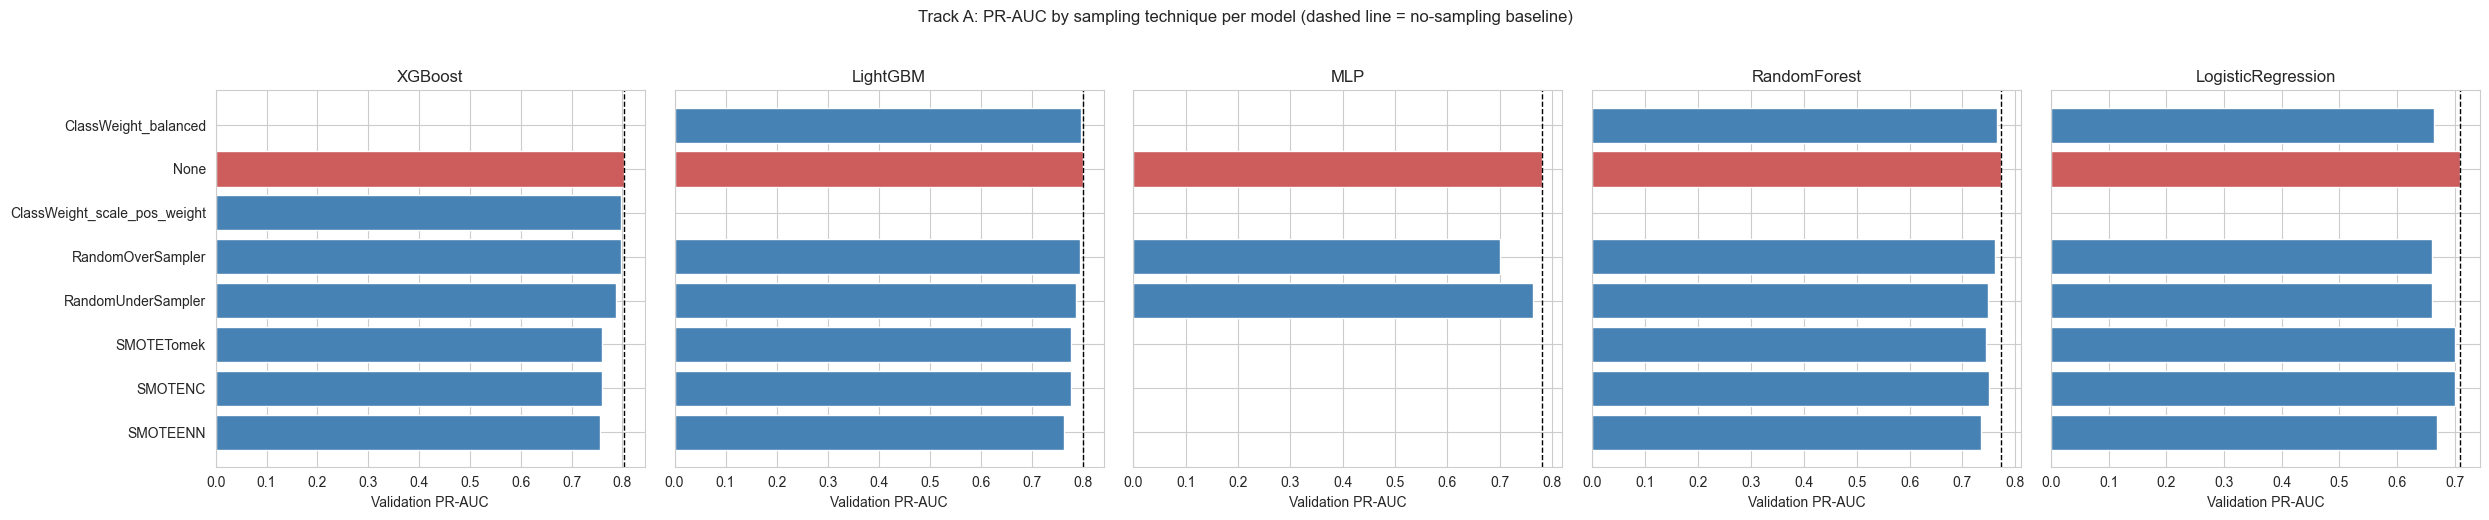

In [4]:
fig, axes = plt.subplots(1, len(MODEL_NAMES := track_a['Model'].unique()), figsize=(5 * len(MODEL_NAMES), 5), sharey=True)
if len(MODEL_NAMES) == 1:
    axes = [axes]

for ax, model in zip(axes, MODEL_NAMES):
    sub = track_a[track_a['Model'] == model].sort_values('Validation_PR_AUC', ascending=True)
    colors = ['indianred' if s == 'None' else 'steelblue' for s in sub['Sampling_Technique']]
    ax.barh(sub['Sampling_Technique'], sub['Validation_PR_AUC'], color=colors)
    ax.axvline(baseline_a.loc[model, 'Validation_PR_AUC'], color='black', linestyle='--', linewidth=1)
    ax.set_title(model)
    ax.set_xlabel('Validation PR-AUC')

plt.suptitle('Track A: PR-AUC by sampling technique per model (dashed line = no-sampling baseline)', y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'track_a_imbalance_pr_auc.png', dpi=120, bbox_inches='tight')
plt.show()


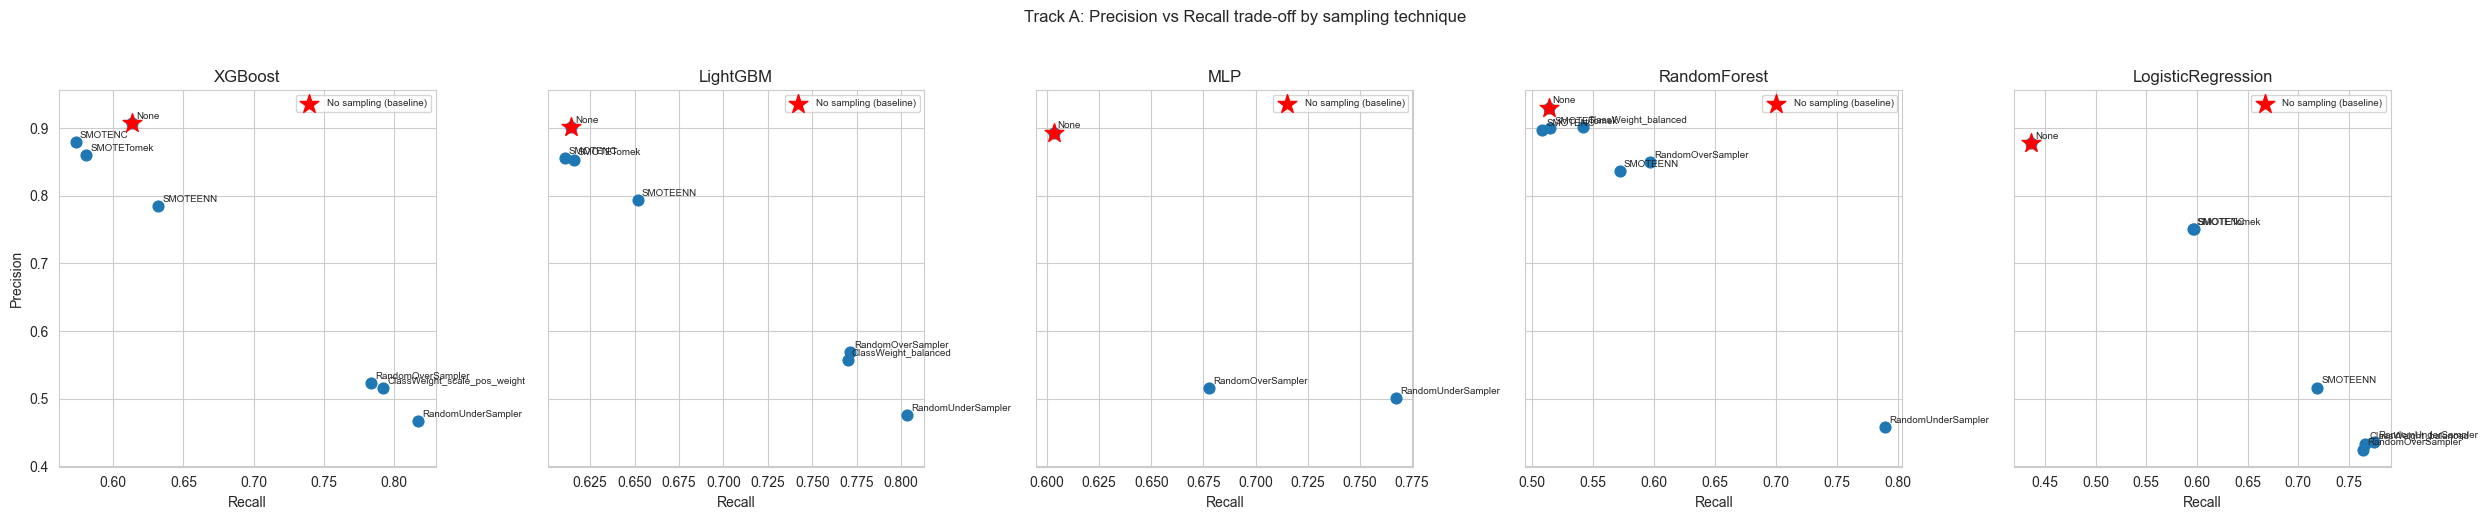

In [5]:
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(5 * len(MODEL_NAMES), 5), sharey=True)
if len(MODEL_NAMES) == 1:
    axes = [axes]

for ax, model in zip(axes, MODEL_NAMES):
    sub = track_a[track_a['Model'] == model]
    ax.scatter(sub['Recall'], sub['Precision'], s=60)
    for _, row in sub.iterrows():
        ax.annotate(row['Sampling_Technique'], (row['Recall'], row['Precision']), fontsize=7,
                    xytext=(3, 3), textcoords='offset points')
    ax.scatter([baseline_a.loc[model, 'Recall']], [baseline_a.loc[model, 'Precision']],
               color='red', marker='*', s=200, zorder=5, label='No sampling (baseline)')
    ax.set_title(model)
    ax.set_xlabel('Recall')
    ax.legend(fontsize=7)
axes[0].set_ylabel('Precision')

plt.suptitle('Track A: Precision vs Recall trade-off by sampling technique', y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'track_a_precision_recall_tradeoff.png', dpi=120, bbox_inches='tight')
plt.show()


## 3. Track B — Redundancy Removal: Full vs Reduced Feature Sets

In [6]:
track_b = results_df[results_df['Sampling_Technique'] == 'None'].copy()
baseline_b = track_b[track_b['Feature_Set'] == 'full'].set_index('Model')

track_b['Baseline_PR_AUC'] = track_b['Model'].map(baseline_b['Validation_PR_AUC'])
track_b['PR_AUC_Delta'] = (track_b['Validation_PR_AUC'] - track_b['Baseline_PR_AUC']).round(4)

track_b_display = track_b[
    ['Model', 'Feature_Set', 'Validation_PR_AUC', 'PR_AUC_Delta', 'Precision', 'Recall', 'F1']
].sort_values(['Model', 'Feature_Set'])
track_b_display


,Model,Feature_Set,Validation_PR_AUC,PR_AUC_Delta,Precision,Recall,F1
5,LightGBM,full,0.8008,0.0000,0.9015,0.6144,0.7308
1,LightGBM,reduced_v1,0.8035,0.0027,0.9128,0.6119,0.7327
4,LightGBM,reduced_v2,0.8010,0.0002,0.9020,0.6070,0.7257
32,LogisticRegression,full,0.7087,0.0000,0.8775,0.4366,0.5831
31,LogisticRegression,reduced_v1,0.7087,0.0000,0.8769,0.4341,0.5807
33,LogisticRegression,reduced_v2,0.7086,-0.0001,0.8772,0.4353,0.5819
14,MLP,full,0.7804,0.0000,0.8932,0.6032,0.7201
12,MLP,reduced_v1,0.7815,0.0011,0.9136,0.5784,0.7083
13,MLP,reduced_v2,0.7813,0.0009,0.9058,0.5983,0.7206
17,RandomForest,full,0.7724,0.0000,0.9302,0.5137,0.6619


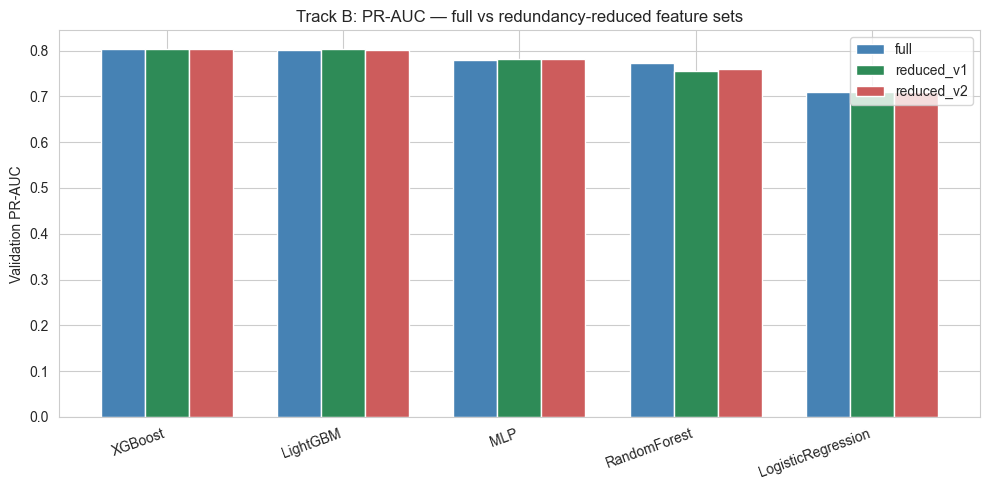

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
models = track_b['Model'].unique()
x = np.arange(len(models))
width = 0.25
fsets = ['full', 'reduced_v1', 'reduced_v2']
colors = ['steelblue', 'seagreen', 'indianred']

for i, fset in enumerate(fsets):
    vals = [track_b[(track_b['Model'] == m) & (track_b['Feature_Set'] == fset)]['Validation_PR_AUC'].values[0]
            if len(track_b[(track_b['Model'] == m) & (track_b['Feature_Set'] == fset)]) > 0 else np.nan
            for m in models]
    ax.bar(x + (i - 1) * width, vals, width, label=fset, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylabel('Validation PR-AUC')
ax.set_title('Track B: PR-AUC — full vs redundancy-reduced feature sets')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'track_b_feature_set_comparison.png', dpi=120)
plt.show()


## 4. Best Configuration Per Model — Batch 2 vs Batch 1

In [8]:
best_per_model = results_df.loc[results_df.groupby('Model')['Validation_PR_AUC'].idxmax()]
best_per_model = best_per_model.merge(
    baseline_a[['Validation_PR_AUC']].rename(columns={'Validation_PR_AUC': 'Batch1_Baseline_PR_AUC'}),
    left_on='Model', right_index=True, how='left'
)
best_per_model['Improvement'] = (best_per_model['Validation_PR_AUC'] - best_per_model['Batch1_Baseline_PR_AUC']).round(4)
best_per_model[['Model', 'Feature_Set', 'Sampling_Technique', 'Validation_PR_AUC',
                'Batch1_Baseline_PR_AUC', 'Improvement', 'Precision', 'Recall', 'F1']].sort_values(
    'Validation_PR_AUC', ascending=False
)


,Model,Feature_Set,Sampling_Technique,Validation_PR_AUC,Batch1_Baseline_PR_AUC,Improvement,Precision,Recall,F1
0,XGBoost,full,None,0.8039,0.8039,0.0000,0.9079,0.6132,0.7320
1,LightGBM,reduced_v1,None,0.8035,0.8008,0.0027,0.9128,0.6119,0.7327
12,MLP,reduced_v1,None,0.7815,0.7804,0.0011,0.9136,0.5784,0.7083
17,RandomForest,full,None,0.7724,0.7724,0.0000,0.9302,0.5137,0.6619
31,LogisticRegression,reduced_v1,None,0.7087,0.7087,0.0000,0.8769,0.4341,0.5807


## 5. Update the Master Comparison Table

In [9]:
master_path = RESULTS_DIR / 'comparison_table.csv'
master_df = pd.read_csv(master_path)
master_df = master_df[master_df['Batch'] != 'Batch_2']
master_df = pd.concat([master_df, results_df], ignore_index=True)
master_df.to_csv(master_path, index=False)
print(f"Master comparison table now has {len(master_df)} rows across all batches so far.")


Master comparison table now has 51 rows across all batches so far.


## 6. Batch 2 Analysis & Hypothesis for Batch 3

### Question 1: Did SMOTE/sampling improve recall?

**Yes, substantially, for every model.** For example:
- XGBoost: recall rose from **0.613** (baseline) to **0.817** (RandomUnderSampler)
- LightGBM: **0.614** to **0.804** (RandomUnderSampler)
- Logistic Regression: **0.437** to **0.597** (SMOTENC/SMOTETomek)
- Random Forest: **0.514** to **0.790** (RandomUnderSampler)
- MLP: **0.603** to **0.767** (RandomUnderSampler)

Every technique tested increased recall over the no-sampling baseline, for
every model. Under-sampling and class-weighting produced the largest
recall gains; the SMOTE-based techniques (SMOTENC, SMOTEENN, SMOTETomek)
produced smaller but still real recall gains.

### Question 2: What happened to precision?

**It dropped, often severely, and the size of the drop tracks the size of
the recall gain.** XGBoost's precision fell from **0.908** (baseline) to
**0.467** (RandomUnderSampler, the same config that gave the biggest
recall boost) -- worse than a coin flip on every positive prediction.
SMOTENC/SMOTETomek were the gentlest on precision (XGBoost: 0.88, 0.86)
while still recovering some recall, but never came close to preserving
baseline precision (0.908).

This is the fundamental trade-off, visible directly in the precision-vs-recall
scatter plot above: every technique moves each model's operating point down
and to the right along roughly the same curve. None of them make the
underlying model better at separating fraud from non-fraud; they just
relocate where on the trade-off curve the default 0.5 threshold happens to land.

### Question 3: Did PR-AUC improve?

**No. For every single model, the no-sampling baseline had the highest
validation PR-AUC of any technique tested**, confirmed programmatically
(not just by inspection) across all 5 models:

| Model | Best technique | Best PR-AUC |
|---|---|---|
| LightGBM | None (baseline) | 0.8008 |
| XGBoost | None (baseline) | 0.8039 |
| Random Forest | None (baseline) | 0.7724 |
| MLP | None (baseline) | 0.7804 |
| Logistic Regression | None (baseline) | 0.7087 |

This is a real, negative finding, stated plainly: **class weighting, SMOTE,
random over/under-sampling, and the combined SMOTEENN/SMOTETomek variants
all increased recall but decreased precision enough that PR-AUC net
decreased, for every model tested.** This matches the exact pattern the
project brief anticipated as a valid possible outcome -- sampling
techniques change *where* on the precision-recall curve a model operates,
not the underlying quality of its ranking, and PR-AUC measures the latter.

**Practical implication worth carrying into Batch 3:** if the real business
goal favors recall over precision (catching more fraud is worth more false
positives), the cheaper and more principled way to get there is
**threshold tuning on the existing Batch 1 baseline models** -- lowering
the classification threshold below 0.5 moves along the same PR curve
without retraining, and by definition cannot reduce PR-AUC (PR-AUC is
threshold-independent), unlike resampling which visibly does. This wasn't
tested in Batch 1 or 2 and is a concrete, well-motivated candidate for
Batch 3.

### Question 4: Did removing redundant features help?

**Mostly no, and for one model it actively hurt.**

- **XGBoost, LightGBM, Logistic Regression, MLP:** differences between
  `full`, `reduced_v1`, and `reduced_v2` are all within +/-0.002-0.003
  PR-AUC -- noise, not signal. This confirms two things: (a) tree/boosting
  models are genuinely invariant to the linear redundancy identified by
  VIF, as expected; and (b) **L1-regularized Logistic Regression's
  performance is completely unchanged (0.7087 to 0.7087 to 0.7086) by
  removing severe multicollinearity** -- the L1 penalty found in Batch 1
  (C=0.1) was already implicitly zeroing out redundant coefficients, so
  manual removal achieves nothing further for *predictive performance* (it
  may still be worth doing for coefficient interpretability, which wasn't
  measured here).

- **Random Forest is the exception, and the effect is real:** PR-AUC
  *dropped* from **0.7724** (full) to **0.7544** (reduced_v1, -0.018) and
  **0.7597** (reduced_v2, -0.013). Losing `Expected_Tax`/`Taxable_Income`/
  `Net_Profit`/etc. cost Random Forest real signal that XGBoost/LightGBM
  didn't need. A plausible explanation: bagged, unboosted trees benefit
  from having several correlated-but-not-identical versions of similar
  signal available at each split (decorrelating individual trees), whereas
  boosting explicitly avoids reusing already-exploited signal round to
  round -- so redundancy helps bagging and is neutral for boosting.

**Conclusion: feature-set reduction is not justified by predictive
performance** for any of the four models where it made no difference, and
is actively counter-productive for Random Forest. It doesn't hurt the top
performers (XGBoost/LightGBM), so it remains a defensible choice for
interpretability/robustness reasons if that were the goal, but the data
doesn't support doing it *for accuracy*.

### Summary: Batch 2 vs Batch 1

**No configuration in Batch 2 beat its own Batch 1 baseline on PR-AUC.**
The best models overall remain XGBoost (0.8039) and LightGBM (0.8008) with
no sampling and the full feature set -- identical to the Batch 1 finding.
This is a legitimate, expected outcome: Batch 2 set out to test two
specific hypotheses (does imbalance handling help; does redundancy removal
help) and got clear, honest "no" answers to both, on the primary PR-AUC
metric. That is a successful experiment, not a wasted one -- it rules out
two plausible-sounding improvements with real evidence instead of
assumption, and surfaces one incidental new lead (threshold tuning) worth
pursuing.

### Hypothesis for Batch 3

**What changed (planned):**
1. **Threshold tuning** on the Batch 1 baseline models (XGBoost, LightGBM
   primarily) -- sweep the classification threshold and report the
   recall/precision trade-off achievable *without* retraining, as the
   principled alternative to resampling that Batch 2 motivates.
2. **Hyperparameter refinement / regularization** -- Batch 1's searches were
   deliberately bounded (see its own notes on trimmed search budgets);
   revisit XGBoost/LightGBM with a wider or more targeted search now that
   they're confirmed as the leaders, and check L1/L2 regularization
   strength for Logistic Regression more finely now that redundancy removal
   is confirmed not to matter.
3. **Model complexity reduction** -- Random Forest and CatBoost both showed
   poor cost/benefit in Batch 1/2 (Random Forest additionally now shown to
   be the one model sensitive to feature redundancy); Batch 3 should decide
   whether either remains worth carrying forward as a finalist.

**Expected result:** threshold tuning should recover meaningful recall
gains at little or no PR-AUC cost (since PR-AUC is threshold-independent by
construction), making it a strictly better lever than resampling for this
dataset. Hyperparameter refinement is expected to produce small,
incremental gains at best given Batch 1's already-strong baselines and
Batch 2's confirmation that no external technique (sampling, redundancy
removal) moves the needle -- the ceiling here may simply be close to
Batch 1/2's current numbers.

**What should change next:** Batch 3 will report, per experiment, whether
each change actually improved validation PR-AUC over the current best
(XGBoost, no sampling, full features, 0.8039), including if it doesn't.
